In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/11001
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

152


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 13
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17068.886839794224
Gradient descend method:  None
RUN  0 , total integrated cost =  17068.886839794224
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  39 0.5250000000000001 0.5250000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  53.693950543928096
RUN  2 , total integrated cost =  43.516233217073356
RUN  3 , total integrated cost =  31.738059230535175
RUN  4 , total integrated cost =  27.315144648752998
RUN  5 , total integrated cost =  22.31412915650445
RUN  6 , total integrated cost =  19.87064721275261
RUN  7 , total integrated cost =  17.289689933054813
RUN  8 , total integrated cost =  15.894475104053106
RUN  9 , total integrated cost =  14.382960616038934
RUN  10 , total integrated cost =  13.43991959921083
RUN  11 , total integrated cost =  12.433284698072876
RUN  12 , total integrated cost =  11.77087964674025
RUN  13 , total integrated cost =  11.09438816572988
RUN  14 , total integrated cost =  10.635716082376437
RUN  15 , total integrated cost =  10.184128611573197
RUN

ERROR:root:Problem in initial value trasfer


RUN  2000 , total integrated cost =  3.997074582509412
RUN  2000 , total integrated cost =  3.997074582509412
Improved over  2000  iterations in  158.07304781489074  seconds by  99.93228059442248  percent.
Problem in initial value trasfer:  Vmean_exc -64.2014764849074 -64.19158555539035
weight =  14766.815973528272
set cost params:  1.0 14766.815973528272 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5507.574270652888
Gradient descend method:  None
RUN  1 , total integrated cost =  5436.351079090252
RUN  2 , total integrated cost =  5436.276650700834
RUN  3 , total integrated cost =  5435.659271495243
RUN  4 , total integrated cost =  5435.136235330447
RUN  5 , total integrated cost =  5434.836979544791
RUN  6 , total integrated cost =  5434.437483746528
RUN  7 , total integrated cost =  5434.371622652352
RUN  8 , total integrated cost =  5434.041853504256
RUN  9 , total integrated cost =  5433.828219843564
RUN  10 , total integrated cost =  5433.337190250

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  63 , total integrated cost =  5411.835983680921
Improved over  63  iterations in  4.9310551434755325  seconds by  1.7383022410085118  percent.
Problem in initial value trasfer:  Vmean_exc -63.72648343752823 -63.753129667017575
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  1 , total integrated cost =  342.581800787402
RUN  2 , total integrated cost =  251.0918479382535
RUN  3 , total integrated cost =  166.01856583639392
RUN  4 , total integrated cost =  141.0912423468385
RUN  5 , total integrated cost =  118.98324105359225
RUN  6 , total integrated cost =  108.71843590850104
RUN  7 , total integrated cost =  99.98848944518822
RUN  8 , total integrated cost =  94.6735924352783
RUN  9 , total integrated cost =  90.15171005712017
RUN  10 , total integrated cost =  87.02910545385295
RUN  11 

...

RUN  20 , total integrated cost =  14076.443916680664
State only changes marginally.
Control only changes marginally.
RUN  22 , total integrated cost =  14076.443916680662
Improved over  22  iterations in  1.6480612009763718  seconds by  2.6736053195956657  percent.
Problem in initial value trasfer:  Vmean_exc -61.69534612470789 -61.735090930530916
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38613.011975189
Gradient descend method:  None
RUN  1 , total integrated cost =  832.5847622375004
RUN  2 , total integrated cost =  545.4450708636458
RUN  3 , total integrated cost =  358.05516925303255
RUN  4 , total integrated cost =  311.5458959596498
RUN  5 , total integrated cost =  271.8052737880202
RUN  6 , total integrated cost =  255.0782382091942
RUN  7 , total integrated cost =  241.80151538806078
RUN  8 , total integrated cost =  233.87734182446195
RUN  9 , total integrated cos

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  185 , total integrated cost =  174.60127801489153
Improved over  185  iterations in  12.892270963639021  seconds by  99.54781751258597  percent.
Problem in initial value trasfer:  Vmean_exc -61.66510017758007 -61.667153782283336
weight =  2211.496525924383
set cost params:  1.0 2211.496525924383 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37406.92793461081
Gradient descend method:  None
RUN  1 , total integrated cost =  34739.859881646524
RUN  2 , total integrated cost =  29831.488523474873
RUN  3 , total integrated cost =  24317.776385867364
RUN  4 , total integrated cost =  24227.916187925657
RUN  5 , total integrated cost =  24216.271664353248
RUN  6 , total integrated cost =  24216.23066049415
RUN  7 , total integrated cost =  24216.230660494144


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  24216.23066049413
RUN  9 , total integrated cost =  24216.23066049413
Control only changes marginally.
RUN  9 , total integrated cost =  24216.23066049413
Improved over  9  iterations in  0.8603887129575014  seconds by  35.26271202268917  percent.
Problem in initial value trasfer:  Vmean_exc -56.698840292395985 -56.70033195274539


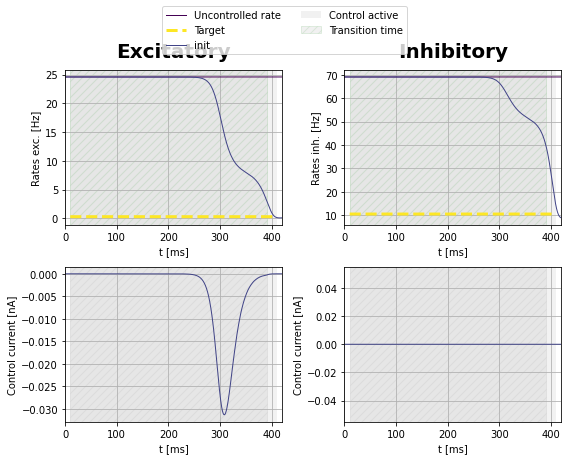

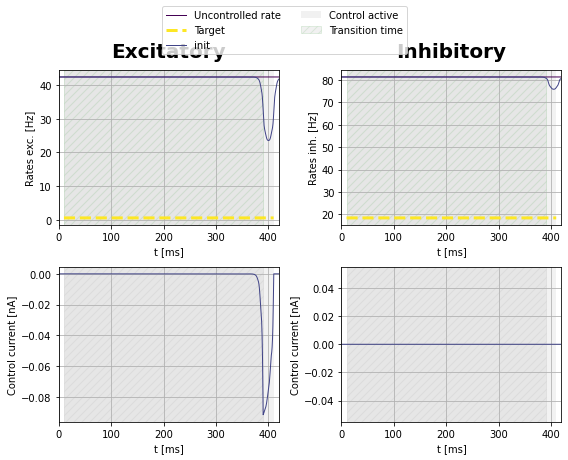

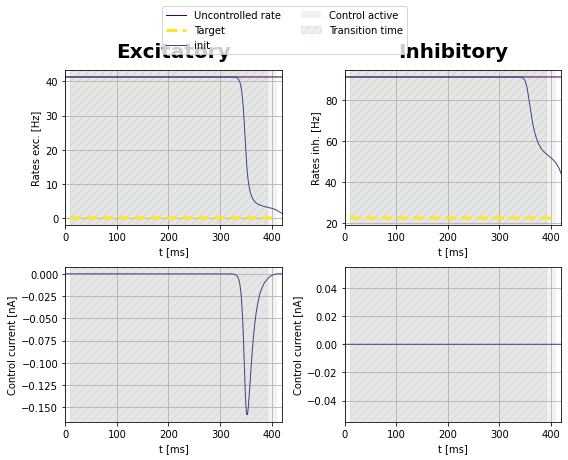

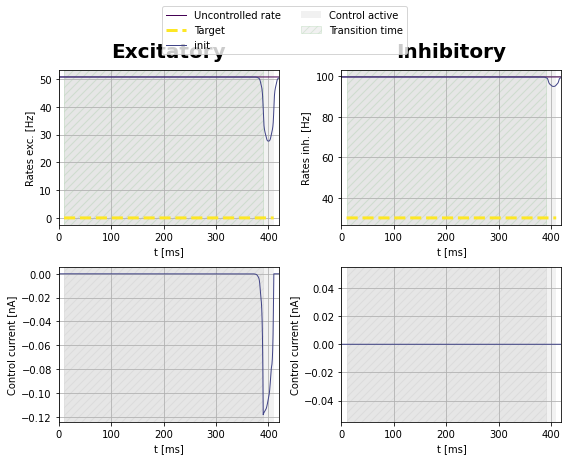

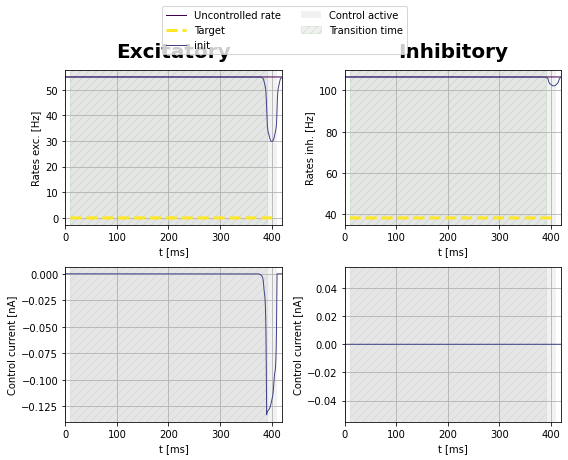

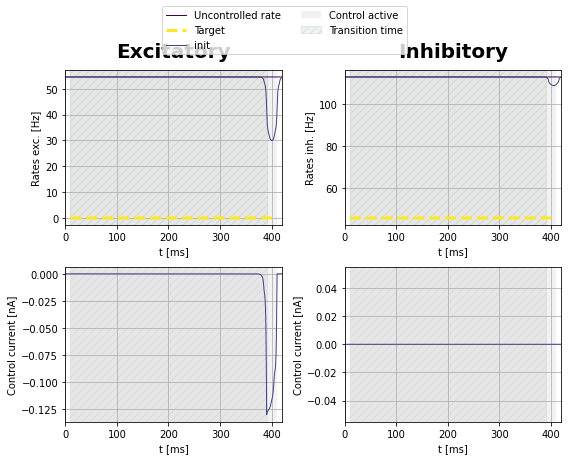

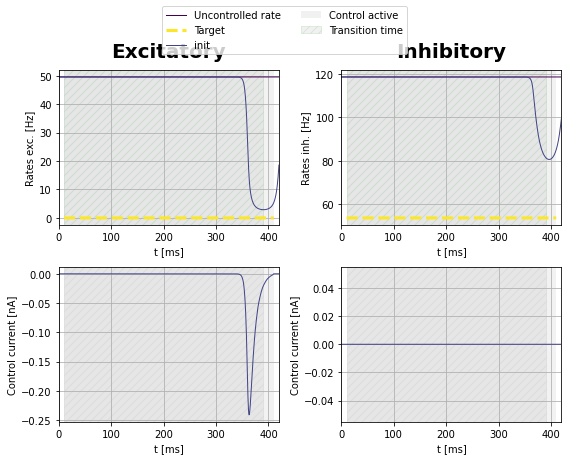

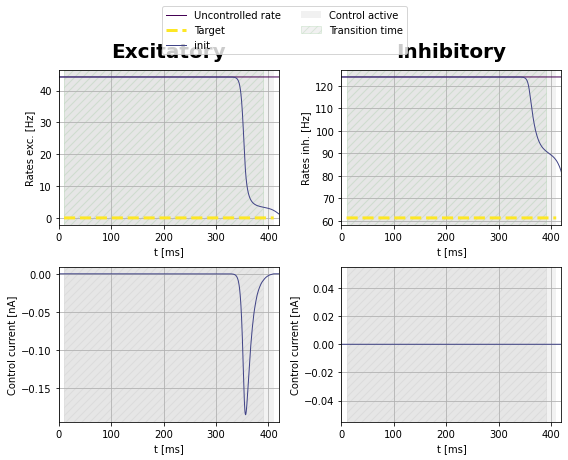

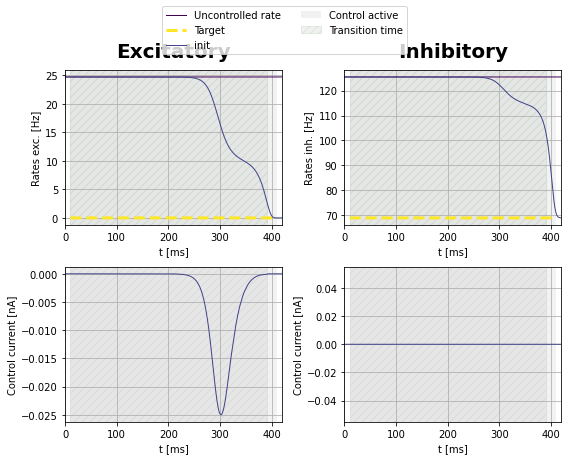

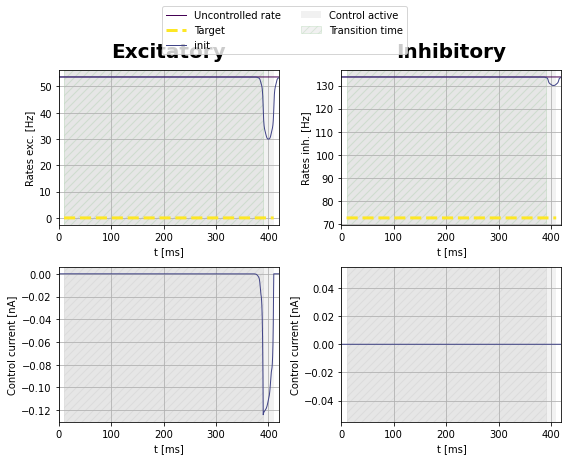

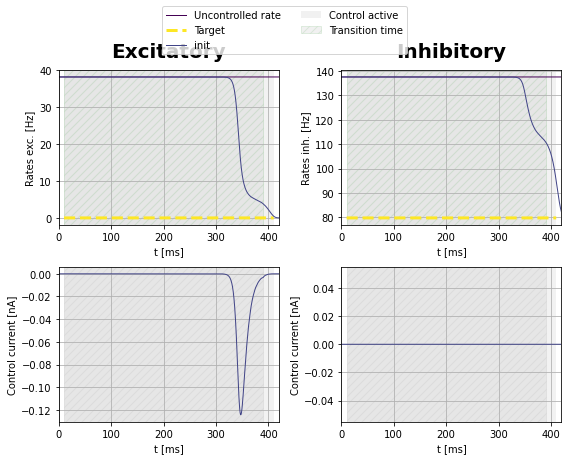

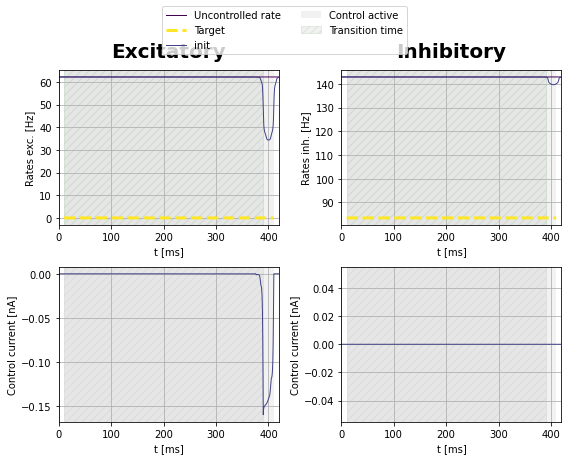

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 152
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  13 0.47500000000000014 0.40000000000000013
[0] []
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
inter

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  448 , total integrated cost =  52.4337598583821
Improved over  448  iterations in  39.7340140696615  seconds by  99.70099809560512  percent.
Problem in initial value trasfer:  Vmean_exc -61.94245199033256 -61.945827403594365
weight =  3347.2991199599483
set cost params:  1.0 3347.2991199599483 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17328.862919740506
Gradient descend method:  None
RUN  1 , total integrated cost =  16402.740771510697
RUN  2 , total integrated cost =  16401.64988187981
RUN  3 , total integrated cost =  16400.276344466027
RUN  4 , total integrated cost =  16399.233126649786
RUN  5 , total integrated cost =  16397.67641872533
RUN  6 , total integrated cost =  16396.393642039933
RUN  7 , total integrated cost =  16393.41367691411
RUN  8 , total integrated cost =  16390.62369401051
RUN  9 , total integrated cost =  16360.874809104573
RUN  10 , total integrated cost =  16349.128881467683
RUN  11 , tota

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  408 , total integrated cost =  11250.455152975115
Improved over  408  iterations in  29.163698263466358  seconds by  35.07678371580316  percent.
Problem in initial value trasfer:  Vmean_exc -56.65381731090852 -56.655343012384364
-------  26 0.47500000000000014 0.4750000000000002
found solution for  26
-------  39 0.5250000000000001 0.5250000000000002
[0, 26] []
closest index  26
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  25197.775418586763
Gradient descend method:  None
RUN  1 , total integrated cost =  558.8554854049864
RUN  2 , total integrated cost =  383.3343009484696
RUN  3 , total integrated cost =  248.85002379785448
RUN  4 , total integrated cost =  213.45869674985747
RUN  5 , total integrated cost =  181.930322237283
RUN  6 , total integrated cost =  168.36917287396994
RUN  7 , total integrated cost =  156.93718986789386
RUN  8 , total integrated cost =  150.

...

RUN  8 , total integrated cost =  18326.508474887964
Control only changes marginally.
RUN  8 , total integrated cost =  18326.508474887964
Improved over  8  iterations in  0.7738309875130653  seconds by  34.76059478420805  percent.
Problem in initial value trasfer:  Vmean_exc -56.68473031113274 -56.686732475088476
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006
[0, 26, 91, 104, 130, 13, 78] [130, 91, 104, 78, 26, 13]
closest index  0
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38598.72456832209
Gradient descend method:  None
RUN  1 , total integrated cost =  835.4140907431831
RUN  2 , total integrated cost =  548.3821154052428
RUN  3 , total integrated cost =  358.878644453091
RUN  4 , total integrated cost =  312.4202120425594
RUN  5 , total integrated cost =  272.59646809778144
RUN  6 , total integrated cost =  255.57515672262278
RUN  7 , total integ

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  239 , total integrated cost =  174.3161026612547
Improved over  239  iterations in  24.573574475944042  seconds by  99.54838895686125  percent.
Problem in initial value trasfer:  Vmean_exc -61.686234553430346 -61.688391124216785
weight =  2215.114460780767
set cost params:  1.0 2215.114460780767 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37442.30075750829
Gradient descend method:  None
RUN  1 , total integrated cost =  34837.60604581642
RUN  2 , total integrated cost =  34745.72641379267
RUN  3 , total integrated cost =  34712.7649132479
RUN  4 , total integrated cost =  34712.20145091228
RUN  5 , total integrated cost =  34711.29269332688
RUN  6 , total integrated cost =  34710.566560488296
RUN  7 , total integrated cost =  34709.38249711065
RUN  8 , total integrated cost =  34708.47299114811
RUN  9 , total integrated cost =  34703.798942980655
RUN  10 , total integrated cost =  34700.32424375483
RUN  11 , total in

ERROR:root:Problem in initial value trasfer


RUN  140 , total integrated cost =  24234.76645102865
Control only changes marginally.
RUN  140 , total integrated cost =  24234.76645102865
Improved over  140  iterations in  12.846058508381248  seconds by  35.2743662629523  percent.
Problem in initial value trasfer:  Vmean_exc -56.69915997503947 -56.70058646960324
------------------------------------------------------------
-------------------- 7
------------------------------------------------------------
found solution:  [0, 26, 91, 104, 130, 13, 78]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
closest index  -1
set cost params:  1.0 10.0 0.0
all options tried already
-------  52 0.5500000000000003 0.5750000000000003
closest index  -1
set cost params:  1.0 10.0 0.0
all options tried already
-------  65 0.5500000000000003 0.6250000000000003
closest index  -1
set

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  16104.393907483398
set cost params:  1.0 16104.393907483398 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5900.523992457893
Gradient descend method:  None
RUN  1 , total integrated cost =  5900.456285047037
RUN  2 , total integrated cost =  5900.456145335031
RUN  3 , total integrated cost =  5900.456142350756
RUN  4 , total integrated cost =  5900.456142341231
RUN  5 , total integrated cost =  5900.456142340166
RUN  6 , total integrated cost =  5900.456142340013
RUN  7 , total integrated cost =  5900.45614233996
RUN  8 , total integrated cost =  5900.456142339955


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  5900.456142339955
Control only changes marginally.
RUN  9 , total integrated cost =  5900.456142339955
Improved over  9  iterations in  1.4283116906881332  seconds by  0.0011498998737238253  percent.
Problem in initial value trasfer:  Vmean_exc -63.61853678383012 -63.64632326611769
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  3567.11869645885
set cost params:  1.0 3567.11869645885 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17543.873103850638
Gradient descend method:  None
RUN  1 , total integrated cost =  17543.84869598591
RUN  2 , total integrated cost =  15304.321270665834
RUN  3 , total integrated cost =  11693.153342111003
RUN  4 , total integrated cost =  11581.777342611123
RUN  5 , total integrated cost =  11563.680670281066
RUN  6 , total integrated cost =  11562.594783894743
RUN  7 , total integrated cost =  11562.568805625768
RUN  8 , total integrated cost =  11562.565127884774
R

ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  11561.375873711444
Control only changes marginally.
RUN  20 , total integrated cost =  11561.375873711444
Improved over  20  iterations in  2.856495847925544  seconds by  34.100208059679346  percent.
Problem in initial value trasfer:  Vmean_exc -56.65598173247071 -56.65746953873437
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  4022.6637541625764
set cost params:  1.0 4022.6637541625764 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17060.978701639997
Gradient descend method:  None
RUN  1 , total integrated cost =  17060.922198771685
RUN  2 , total integrated cost =  17060.922186667107
RUN  3 , total integrated cost =  17060.922186667096


...

RUN  3 , total integrated cost =  27998.087453550324
Control only changes marginally.
RUN  3 , total integrated cost =  27998.087453550324
Improved over  3  iterations in  0.7258149981498718  seconds by  0.02817552252996336  percent.
Problem in initial value trasfer:  Vmean_exc -56.70396689327211 -56.70401840984676
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
no convergence
weight =  19765.062884883417
set cost params:  1.0 19765.062884883417 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  26995.461887828933
Gradient descend method:  None
RUN  1 , total integrated cost =  26988.008255816316
RUN  2 , total integrated cost =  26988.00338426783
RUN  3 , total integrated cost =  26988.003384267504
RUN  4 , total integrated cost =  26988.00338426748
RUN  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  8 , total integrated cost =  26988.003384267453
Improved over  8  iterations in  1.2703162599354982  seconds by  0.02762873105291419  percent.
Problem in initial value trasfer:  Vmean_exc -56.70338057199872 -56.70347029273031
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  143 0.6000000000000003 0.8750000000000006
no convergence
weight =  17307.596893940423
set cost params:  1.0 17307.596893940423 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  36281.7164521981
Gradient descend method:  None
RUN  1 , total integrated cost =  36271.13510291607
RUN  2 , total integrated cost =  36271.13510291606
RUN  3 , total integrated cost =  36271.13510291605
RUN  4 , total integrated cost =  36271.13510291604


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  36271.13510291604
Control only changes marginally.
RUN  5 , total integrated cost =  36271.13510291604
Improved over  5  iterations in  1.1625142712146044  seconds by  0.029164412042078425  percent.
Problem in initial value trasfer:  Vmean_exc -56.70224414635123 -56.70207219748941


In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [False, False], [True, True], [False, False], [False, False], [False, False], [True, True], [True, True], [True, True], [False, False], [True, True], [False, False]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  26.911704437799024
Gradient descend method:  None
RUN  1 , total integrated cost =  8.951357392698895
RUN  2 , total integrated cost =  8.94953825564186
RUN  3 , total integrated cost =  8.945446832513511
RUN  4 , total integrated cost =  8.942855659896802
RUN  5 , total integrated cost =  8.930461139707116
RUN  6 , total integrated cost =  8.917628339559746
RUN  7 , total integrated cost =  8.901501883913745
RUN  8 , total integrated cost =  8.901479622409266
RUN  9 , total integrated cost =  8.901475248663427
RUN  10 , total integrated cost =  8.901455108999567
RUN  11 , total integrated cost =  8.901418997940517
RUN  12 , total integrated cost =  8.901415226258846
RUN  13 , total integrated cost =  8.901386335718962
RUN  14 , total integrated cost =  8.901370764546007
RUN  15 , total integrated cost =  8.901349540168766
RUN  16 , tot

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  279 , total integrated cost =  8.65293924216957
Improved over  279  iterations in  126.52722399495542  seconds by  67.84692971725707  percent.
Problem in initial value trasfer:  Vmean_exc -62.79061125552083 -62.78943323980954
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37.17735300702678
Gradient descend method:  HS
RUN  1 , total integrated cost =  36.60038710962628
RUN  2 , total integrated cost =  36.60012213437534
RUN  3 , total integrated cost =  36.58481462310025
RUN  4 , total integrated cost =  36.54370923381982
RUN  5 , total integrated cost =  36.53296952512954
RUN  6 , total integrated cost =  36.53105733384946
RUN  7 , total integrated cost =  36.526768527078026
RUN  8 , total integrated cost =  36.52676852707793
RUN  9 , total integrated cost =  36.52024198495389
RUN  10 , total integrated cost =  36.51481962495976
RUN  11 , total integrated cost =  36.51391825282

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  416 , total integrated cost =  35.78122719645495
Improved over  416  iterations in  106.29926837421954  seconds by  3.755312569746309  percent.
Problem in initial value trasfer:  Vmean_exc -62.83883051323305 -62.83571179980985
weight =  16494.819013784883
set cost params:  1.0 16494.819013784883 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5888.78154715516
Gradient descend method:  None
RUN  1 , total integrated cost =  5860.644552103965
RUN  2 , total integrated cost =  5860.3833994883835
RUN  3 , total integrated cost =  5860.334469098306
RUN  4 , total integrated cost =  5860.300511955535
RUN  5 , total integrated cost =  5860.297850501947
RUN  6 , total integrated cost =  5860.288426891661
RUN  7 , total integrated cost =  5860.286350499659
RUN  8 , total integrated cost =  5860.28489537633
RUN  9 , total integrated cost =  5860.275574062806
RUN  10 , total integrated cost =  5860.272533043526
RUN  11 , total inte

...

Control only changes marginally.
RUN  205 , total integrated cost =  59.98091156221411
Improved over  205  iterations in  65.19092787243426  seconds by  99.82373487899856  percent.
Problem in initial value trasfer:  Vmean_exc -63.539775227307786 -63.54625021921821
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1750.9311939080958
Gradient descend method:  HS
RUN  1 , total integrated cost =  1654.3166179395184
RUN  2 , total integrated cost =  1648.7459409882879
RUN  3 , total integrated cost =  1647.3896766180771
RUN  4 , total integrated cost =  1647.3884866947765
RUN  5 , total integrated cost =  1647.3638522862998
RUN  6 , total integrated cost =  1647.3531544341838
RUN  7 , total integrated cost =  1647.3529883455635
RUN  8 , total integrated cost =  1647.2525636776597
RUN  9 , total integrated cost =  1647.2525352170437
RUN  10 , total integrated cost =  1647.2525072894023
RUN  11 , total integrated cost =  164

ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  1647.2524983987532
Control only changes marginally.
RUN  15 , total integrated cost =  1647.2524983987532
Improved over  15  iterations in  3.1331049278378487  seconds by  5.921346074024228  percent.
Problem in initial value trasfer:  Vmean_exc -59.21347434508396 -59.19888249958744
weight =  2343.085804254272
set cost params:  1.0 2343.085804254272 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38052.86831353915
Gradient descend method:  None
RUN  1 , total integrated cost =  37217.511823856796
RUN  2 , total integrated cost =  37216.51141009755
RUN  3 , total integrated cost =  37216.17963624252
RUN  4 , total integrated cost =  37215.7394219064
RUN  5 , total integrated cost =  37215.54237115819
RUN  6 , total integrated cost =  37215.18434232455
RUN  7 , total integrated cost =  37214.97094299649
RUN  8 , total integrated cost =  37214.544478521726
RUN  9 , total integrated cost =  34185.831426724995
RUN  10 , total int

ERROR:root:Problem in initial value trasfer


RUN  17 , total integrated cost =  24823.47416325305
Control only changes marginally.
RUN  17 , total integrated cost =  24823.47416325305
Improved over  17  iterations in  3.0325810723006725  seconds by  34.765826432009334  percent.
Problem in initial value trasfer:  Vmean_exc -56.70030125648649 -56.70149030875872


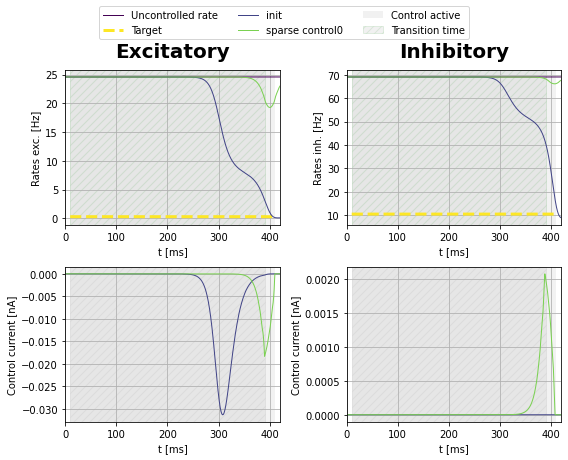

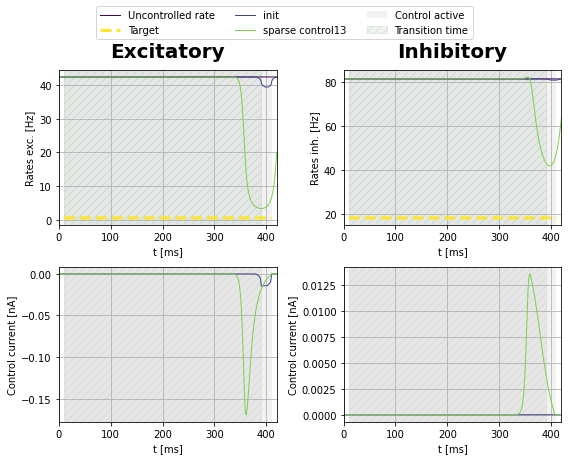

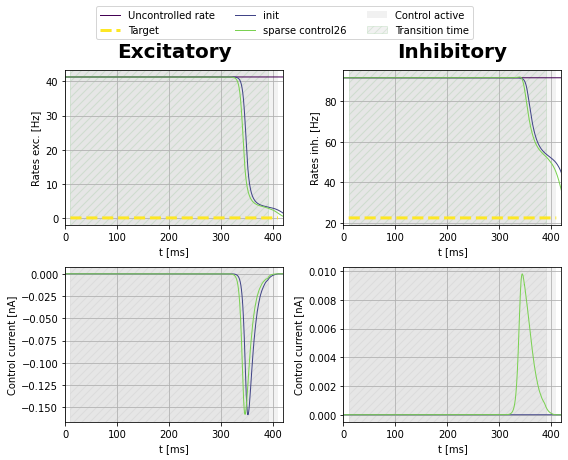

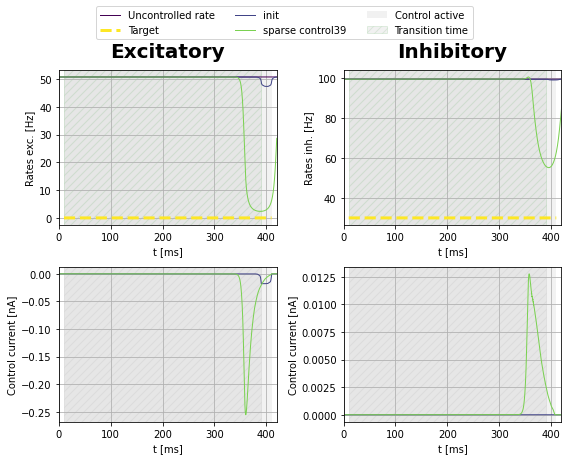

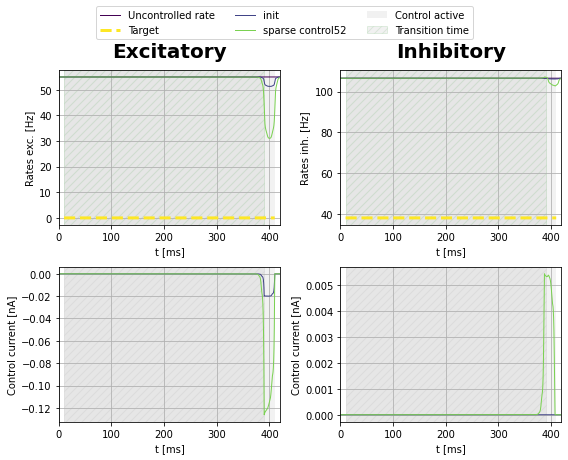

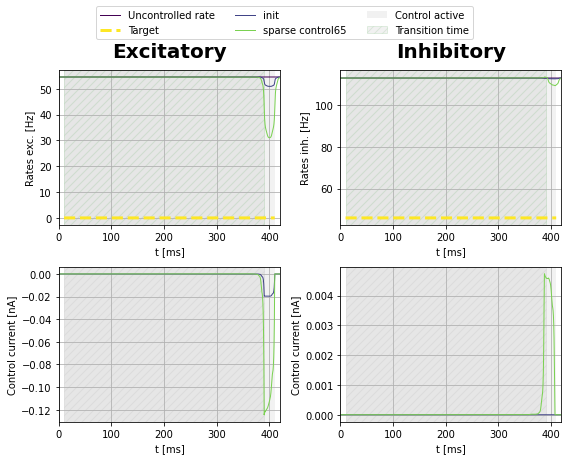

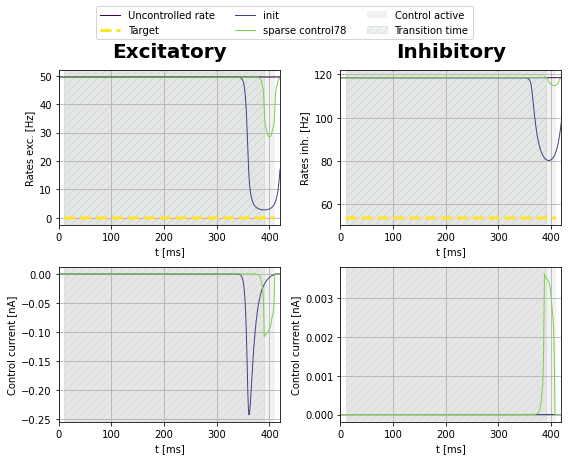

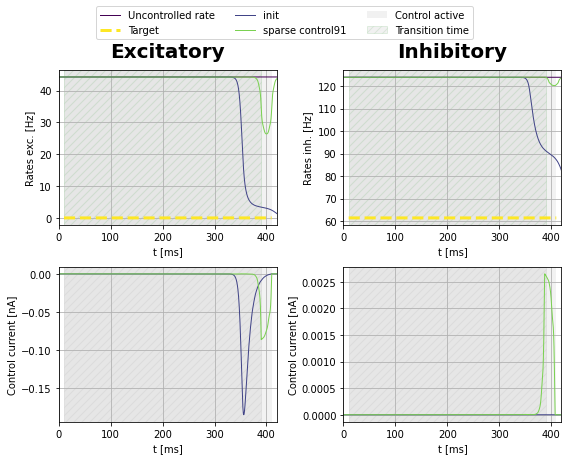

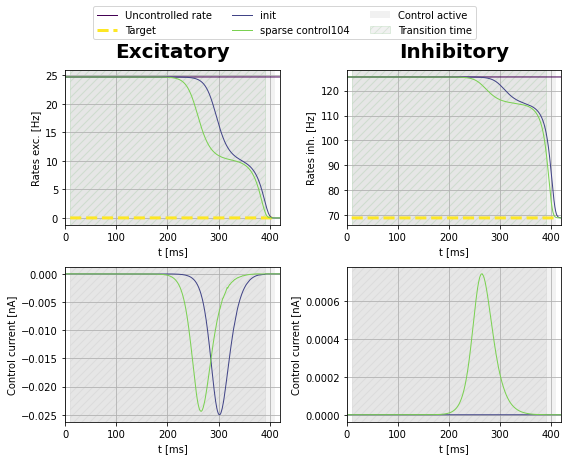

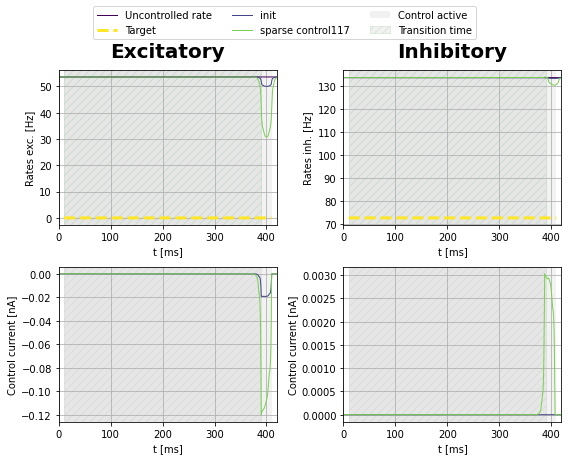

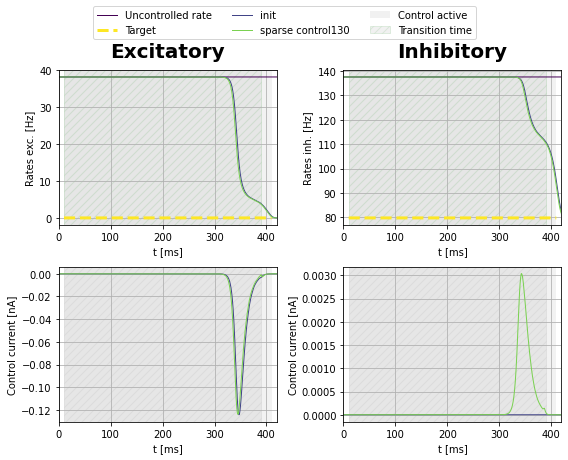

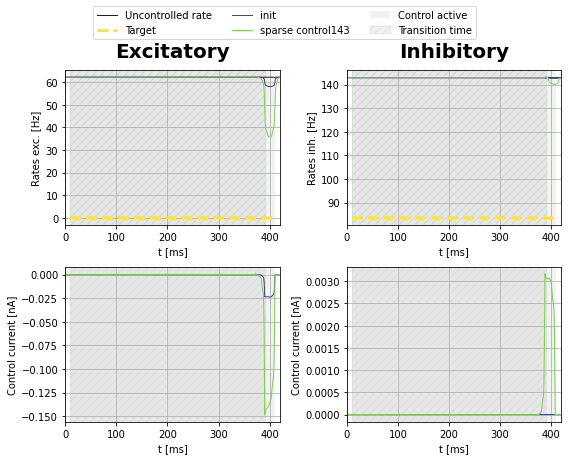

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  20202.657993209126
set cost params:  1.0 20202.657993209126 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5051.771357170967
Gradient descend method:  None
RUN  1 , total integrated cost =  5012.681415134871
RUN  2 , total integrated cost =  5012.2602685924
RUN  3 , total integrated cost =  5012.259121004097
RUN  4 , total integrated cost =  5012.259114069703
RUN  5 , total integrated cost =  5012.259114065323
RUN  6 , total integrated cost =  5012.259114065306
RUN  7 , total integrated cost =  5012.259114065301
RUN  8 , total integrated cost =  5012.259114065299


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  5012.259114065299
Control only changes marginally.
RUN  9 , total integrated cost =  5012.259114065299
Improved over  9  iterations in  1.777539098635316  seconds by  0.7821463069499544  percent.
Problem in initial value trasfer:  Vmean_exc -56.626692194538954 -56.62663078763234
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  3623.7410206919244
set cost params:  1.0 3623.7410206919244 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17541.48969479732
Gradient descend method:  None
RUN  1 , total integrated cost =  17541.438750952988
RUN  2 , total integrated cost =  17541.438188573527
RUN  3 , total integrated cost =  17541.438154419906
RUN  4 , total integrated cost =  17541.438152751347
RUN  5 , total integrated cost =  17541.438151270995
RUN  6 , total integrated cost =  17541.438149735353
RUN  7 , total integrated cost =  17541.438147890334
RUN  8 , total integrated cost =  17541.438145911397


ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  17541.43814580452
RUN  13 , total integrated cost =  17541.43814580452
Control only changes marginally.
RUN  13 , total integrated cost =  17541.43814580452
Improved over  13  iterations in  2.708500452339649  seconds by  0.00029386895695893145  percent.
Problem in initial value trasfer:  Vmean_exc -57.433786560609555 -57.422799824265596
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  4049.9604537936166
set cost params:  1.0 4049.9604537936166 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17063.804888198596
Gradient descend method:  None
RUN  1 , total integrated cost =  17063.800548157513
RUN  2 , total integrated cost =  17063.800547853938
RUN  3 , total integrated cost =  17063.800547846888
RUN  4 , total integrated cost =  17063.800547846855
RUN  5 , total integrated cost =  17063.800547846822


...

RUN  4 , total integrated cost =  19426.274822092142
Control only changes marginally.
RUN  4 , total integrated cost =  19426.274822092142
Improved over  4  iterations in  1.2586744911968708  seconds by  8.480348297723594e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.693569044149406 -56.69360133372341
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
no convergence
weight =  129309.09931794714
set cost params:  1.0 129309.09931794714 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28443.13434170545
Gradient descend method:  None
RUN  1 , total integrated cost =  28443.10920947082
RUN  2 , total integrated cost =  28443.109209470796


ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  28443.109209470796
Control only changes marginally.
RUN  3 , total integrated cost =  28443.109209470796
Improved over  3  iterations in  0.8910879660397768  seconds by  8.835958213637696e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.704019098707526 -56.704026988380434
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  143 0.6000000000000003 0.8750000000000006
no convergence
weight =  114139.85493771295
set cost params:  1.0 114139.85493771295 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38246.18671973592
Gradient descend method:  None
RUN  1 , total integrated cost =  38246.153156942484
RUN  2 , total integrated cost =  38246.153148211706
RUN  3 , total integrated cost =  38246.153148202684
RUN  4 , total integrated cost =  38246.153148202655
RUN  5 , total integrated cost =  38246.15314820265


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  38246.15314820265
Control only changes marginally.
RUN  6 , total integrated cost =  38246.15314820265
Improved over  6  iterations in  1.4311863388866186  seconds by  8.777746528210173e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.700615054300066 -56.7005785830277
--------------- 101


In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[False, False], [True, True], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [True, True], [False, False]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5794.319348934201
Gradient descend method:  None
RUN  1 , total integrated cost =  8.622412599467797
RUN  2 , total integrated cost =  7.4223725225858574
RUN  3 , total integrated cost =  5.68342639985636
RUN  4 , total integrated cost =  5.002240937872803
RUN  5 , total integrated cost =  4.087996747717791
RUN  6 , total integrated cost =  3.6502513824140017
RUN  7 , total integrated cost =  3.1534498417902848
RUN  8 , total integrated cost =  2.892339001744168
RUN  9 , total integrated cost =  2.3784016277842257
RUN  10 , total integrated cost =  2.087627550983849
RUN  11 , total integrated cost =  1.690297355999359
RUN  12 , total integrated cost =  1.4711165044898191
RUN  13 , total integrated cost =  1.0646855382796436
RUN  14 , total integrated cost =  0.8361526156639737
RUN  15 , total integrated cost =  0.8326225209444473
RUN  16

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  519 , total integrated cost =  0.518479890115905
Improved over  519  iterations in  33.16855093277991  seconds by  99.99105192760541  percent.
Problem in initial value trasfer:  Vmean_exc -63.11141956692265 -63.1078394400556
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  149.25544830592685
Gradient descend method:  None
RUN  1 , total integrated cost =  5.623859486640605
RUN  2 , total integrated cost =  5.617990192538107
RUN  3 , total integrated cost =  5.609941833859245
RUN  4 , total integrated cost =  5.6054661246008575
RUN  5 , total integrated cost =  5.59664884724996
RUN  6 , total integrated cost =  5.589890410162816
RUN  7 , total integrated cost =  5.553007467149817
RUN  8 , total integrated cost =  5.5173814079731045
RUN  9 , total integrated cost =  5.241377243374237
RUN  10 , total integrated cost =  5.241283181407141
RUN  11 , t

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  262 , total integrated cost =  5.202802101246737
Improved over  262  iterations in  16.49748625420034  seconds by  96.51416269201603  percent.
Problem in initial value trasfer:  Vmean_exc -61.708005540007846 -61.70840650356791
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  57.6432301312447
Gradient descend method:  None
RUN  1 , total integrated cost =  4.421373566183394
RUN  2 , total integrated cost =  4.42085217469784
RUN  3 , total integrated cost =  4.420843851574573
RUN  4 , total integrated cost =  4.420838660889861
RUN  5 , total integrated cost =  4.420736046948505
RUN  6 , total integrated cost =  4.4204876006101586
RUN  7 , total integrated cost =  4.420473241394397
RUN  8 , total integrated cost =  4.42046859561313
RUN  9 , total integrated cost =  4.420313739724762
RUN  10 , total integrated cost =  4.420007356440064
RUN  11 , tota

...

RUN  300 , total integrated cost =  10.936166063957275
Control only changes marginally.
RUN  301 , total integrated cost =  10.936166063957275
Improved over  301  iterations in  19.334766946732998  seconds by  99.96118084840697  percent.
Problem in initial value trasfer:  Vmean_exc -66.6484742813177 -66.66619622928357
-------  130 0.47500000000000014 0.8500000000000005
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  52.76643803235261
Gradient descend method:  None
RUN  1 , total integrated cost =  2.94541994048013
RUN  2 , total integrated cost =  2.945091268617501
RUN  3 , total integrated cost =  2.945088909792303
RUN  4 , total integrated cost =  2.945086678150136
RUN  5 , total integrated cost =  2.945045467614902
RUN  6 , total integrated cost =  2.9449417814144416
RUN  7 , total integrated cost =  2.944937279281215
RUN  8 , total integrated cost =  2.9449351425824717
RUN  9 , total integrated cost =  2.9449013978715888
RUN  10

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  58 , total integrated cost =  2.9410529751654155
Improved over  58  iterations in  3.7504546251147985  seconds by  94.42628101339308  percent.
Problem in initial value trasfer:  Vmean_exc -72.17915172708649 -72.20833359765071
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37882.46613852384
Gradient descend method:  None
RUN  1 , total integrated cost =  181.56592384112494
RUN  2 , total integrated cost =  79.12062627754186
RUN  3 , total integrated cost =  26.01391606753892
RUN  4 , total integrated cost =  25.333651760532526
RUN  5 , total integrated cost =  24.850924159349155
RUN  6 , total integrated cost =  24.370896805531178
RUN  7 , total integrated cost =  23.99201821488763
RUN  8 , total integrated cost =  23.66764490067571
RUN  9 , total integrated cost =  23.38064829018486
RUN  10 , total integrated cost =  23.136893067749458
RUN  11 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  293 , total integrated cost =  17.79920129530924
Improved over  293  iterations in  18.77193457260728  seconds by  99.95301467114041  percent.
Problem in initial value trasfer:  Vmean_exc -64.03831145305347 -64.0443922813632


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.518479890115905
Gradient descend method:  None
RUN  1 , total integrated cost =  0.518479890115905
Control only changes marginally.
RUN  1 , total integrated cost =  0.518479890115905
Improved over  1  iterations in  0.1560624148696661  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -63.11141956692265 -63.1078394400556
-------  13 0.47500000000000014 0.40000000000000013
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5.202802101246737
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5.202802101246737
Control only changes marginally.
RUN  1 , total integrated cost =  5.202802101246737
Improved over  1  iterations in  0.16010993905365467  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -61.708005540007846 -61.70840650356791
-------  26 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4.4157257466734645
Gradient descend method:  None
RUN  1 , total integrated cost =  4.4157257466734645
Control only changes marginally.
RUN  1 , total integrated cost =  4.4157257466734645
Improved over  1  iterations in  0.15841192565858364  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -66.81347478456789 -66.82193272254071
-------  39 0.5250000000000001 0.5250000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9.5293476962

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  5.426930142640669
Control only changes marginally.
RUN  1 , total integrated cost =  5.426930142640669
Improved over  1  iterations in  0.15771472826600075  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -69.67125919076844 -69.69441915983631
-------  104 0.4250000000000001 0.7750000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.2515882067326633
Gradient descend method:  None
RUN  1 , total integrated cost =  0.2515882067326633
Control only changes marginally.
RUN  1 , total integrated cost =  0.2515882067326633
Improved over  1  iterations in  0.15256337635219097  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -76.27642229998997 -76.30610330711615
-------  117 0.5500000000000003 0.8000000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10.936166063

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  10.936166063957275
Control only changes marginally.
RUN  1 , total integrated cost =  10.936166063957275
Improved over  1  iterations in  0.16013439744710922  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -66.6484742813177 -66.66619622928357
-------  130 0.47500000000000014 0.8500000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.9410529751654155
Gradient descend method:  None
RUN  1 , total integrated cost =  2.9410529751654155
Control only changes marginally.
RUN  1 , total integrated cost =  2.9410529751654155
Improved over  1  iterations in  0.15537643991410732  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -72.17915172708649 -72.20833359765071
-------  143 0.6000000000000003 0.8750000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17.7992012

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  17.79920129530924
Control only changes marginally.
RUN  1 , total integrated cost =  17.79920129530924
Improved over  1  iterations in  0.15920765697956085  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -64.03831145305347 -64.0443922813632
--------------- 12
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
